In [39]:
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import platform

# ==========================================
# 0. 시각화 한글 폰트 설정
# ==========================================
if platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # Windows
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 1. 실시간 날씨 데이터 수집 (Open-Meteo API)
# ==========================================
print("1단계: Open-Meteo API를 통해 서울 기상 데이터 수집 중...")
# [수정포인트 1] 주소를 v1/forecast에서 v1/archive 로 변경!
# [수정포인트 2] start_date와 end_date를 명시하고 다른 날짜 옵션은 완전 제거!
url = "https://archive-api.open-meteo.com/v1/archive?latitude=37.5665&longitude=126.9780&start_date=2025-01-01&end_date=2025-12-31&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,rain"

response = requests.get(url)
data = response.json()

# API 명세상 archive 서버는 응답 구조가 동일합니다.
hourly_data = data['hourly']
df = pd.DataFrame({
    '측정시간': hourly_data['time'],
    '기온(°C)': hourly_data['temperature_2m'],
    '상대습도(%)': hourly_data['relative_humidity_2m'],
    '지면기압(hPa)': hourly_data['surface_pressure'],
    '풍속(km/h)': hourly_data['wind_speed_10m'],
    '강수량(mm)': hourly_data['rain']
})

print(f"성공적으로 {len(df)}행의 1년 치 데이터를 불러왔습니다!")
df

1단계: Open-Meteo API를 통해 서울 기상 데이터 수집 중...
성공적으로 8760행의 1년 치 데이터를 불러왔습니다!


,측정시간,기온(°C),상대습도(%),지면기압(hPa),풍속(km/h),강수량(mm)
0,2025-01-01T00:00,0.7,65,1018.2,7.3,0.0
1,2025-01-01T01:00,0.2,57,1019.4,2.0,0.0
2,2025-01-01T02:00,2.5,53,1019.5,2.1,0.0
3,2025-01-01T03:00,4.8,53,1018.8,4.6,0.0
4,2025-01-01T04:00,6.2,52,1017.9,8.3,0.0
...,...,...,...,...,...,...
8755,2025-12-31T19:00,-9.8,44,1024.2,11.3,0.0
8756,2025-12-31T20:00,-10.1,42,1024.1,11.5,0.0
8757,2025-12-31T21:00,-10.4,40,1023.9,10.6,0.0
8758,2025-12-31T22:00,-10.6,38,1023.9,9.7,0.0


In [40]:

# ==========================================
# 2. 결측치 처리 및 분류형 정답(Target) 레이블 생성
# ==========================================
print("2단계: 미래 예보로 인한 결측치 제거 및 한글 정답 레이블 생성 중...")

# [중요] 미래 예보 구간의 강수량 등 NaN으로 들어오는 결측치 행을 깔끔하게 제거
df = df.dropna().reset_index(drop=True)

# 강수량이 0mm 초과이면 '비 옴(1)', 아니면 '맑음(0)'으로 이진 분류 레이블 생성
df['강수여부(정답)'] = (df['강수량(mm)'] > 0).astype(int)

# 입력 특성(X)으로 사용할 한글 컬럼 정의 및 스케일링
select_col = ['기온(°C)', '상대습도(%)', '지면기압(hPa)', '풍속(km/h)']
scaler = MinMaxScaler()
df[select_col] = scaler.fit_transform(df[select_col])
df

2단계: 미래 예보로 인한 결측치 제거 및 한글 정답 레이블 생성 중...


,측정시간,기온(°C),상대습도(%),지면기압(hPa),풍속(km/h),강수량(mm),강수여부(정답)
0,2025-01-01T00:00,0.274472,0.597701,0.6975,0.250000,0.0,0
1,2025-01-01T01:00,0.264875,0.505747,0.7275,0.068493,0.0,0
2,2025-01-01T02:00,0.309021,0.459770,0.7300,0.071918,0.0,0
3,2025-01-01T03:00,0.353167,0.459770,0.7125,0.157534,0.0,0
4,2025-01-01T04:00,0.380038,0.448276,0.6900,0.284247,0.0,0
...,...,...,...,...,...,...,...
8755,2025-12-31T19:00,0.072937,0.356322,0.8475,0.386986,0.0,0
8756,2025-12-31T20:00,0.067179,0.333333,0.8450,0.393836,0.0,0
8757,2025-12-31T21:00,0.061420,0.310345,0.8400,0.363014,0.0,0
8758,2025-12-31T22:00,0.057582,0.287356,0.8400,0.332192,0.0,0


In [41]:
df['강수여부(정답)'].value_counts()

강수여부(정답)
0    7506
1    1254
Name: count, dtype: int64

In [42]:

# ==========================================
# 3. 시계열 분류 커스텀 Dataset 및 DataLoader 정의
# ==========================================
class WeatherClassificationDS(Dataset):
    def __init__(self, _df, _feature_cols, _window):
        self.x_data = _df[_feature_cols].values
        self.y_data = _df['강수여부(정답)'].values
        self.window = _window
        self.n = len(_df) - _window

    def __len__(self):
        return max(self.n, 1)

    def __getitem__(self, idx):
        # 입력 데이터: 과거 window(72시간)만큼의 한글 특성 흐름
        x_window = self.x_data[idx : idx + self.window]
        
        # 정답 데이터: 72시간 흐름 바로 다음 시점의 강수 여부 (0 또는 1)
        y_next = self.y_data[idx + self.window]
        
        # 파이토치 텐서 변환 (정답은 반드시 정수형인 .long() 필수)
        x_tensor = torch.tensor(x_window).float() 
        y_tensor = torch.tensor(y_next).long()         
        
        return x_tensor, y_tensor

# 과거 72시간(3일)의 흐름을 보고 다음 시간의 강수 여부를 예측
seq_length = 72
weather_dataset = WeatherClassificationDS(df, select_col, seq_length)

# 셔플을 True로 주어 모델이 골고루 분류 규칙을 배우게 합니다.
train_loader = DataLoader(weather_dataset, batch_size=64, shuffle=True)


In [43]:

# ==========================================
# 4. 분류형 LSTM 모델 아키텍처 정의
# ==========================================
class WeatherClassifierLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=32, num_classes=2):
        super(WeatherClassifierLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        # 최종 출력을 클래스 개수(2개: 맑음/비)로 설정
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (Batch, Sequence=72, Feature=4)
        lstm_out, _ = self.lstm(x)
        # 맨 마지막(72번째) 시점의 은닉 상태를 선형 레이어로 전달
        logits = self.fc(lstm_out[:, -1, :]) 
        return logits # 각 클래스별 예측 점수 (Batch, 2)

# 모델 생성 (특성 4개 입력 -> 클래스 2개 분류)
model = WeatherClassifierLSTM(input_size=4, hidden_size=32, num_classes=2)

# ==========================================
# 5. 모델 학습 루프 (Training Loop)
# ==========================================
print("3단계: 한글 데이터셋 기반 LSTM 분류 모델 학습 시작...")

criterion = nn.CrossEntropyLoss() # 분류용 교차 엔트로피 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

model.train()
for epoch in range(15):
    total_loss = 0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # 실시간 훈련 정확도(Accuracy) 계산 리포팅
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    print(f"   에포크 [{epoch+1}/15] -> Loss(오차): {total_loss/len(train_loader):.4f} | 정확도: {(correct/total)*100:.2f}%")


3단계: 한글 데이터셋 기반 LSTM 분류 모델 학습 시작...
   에포크 [1/15] -> Loss(오차): 0.3853 | 정확도: 85.69%
   에포크 [2/15] -> Loss(오차): 0.3072 | 정확도: 87.17%
   에포크 [3/15] -> Loss(오차): 0.2936 | 정확도: 87.95%
   에포크 [4/15] -> Loss(오차): 0.2825 | 정확도: 88.42%
   에포크 [5/15] -> Loss(오차): 0.2749 | 정확도: 88.87%
   에포크 [6/15] -> Loss(오차): 0.2696 | 정확도: 89.02%
   에포크 [7/15] -> Loss(오차): 0.2640 | 정확도: 89.08%
   에포크 [8/15] -> Loss(오차): 0.2611 | 정확도: 89.39%
   에포크 [9/15] -> Loss(오차): 0.2597 | 정확도: 89.36%
   에포크 [10/15] -> Loss(오차): 0.2550 | 정확도: 89.42%
   에포크 [11/15] -> Loss(오차): 0.2488 | 정확도: 89.56%
   에포크 [12/15] -> Loss(오차): 0.2431 | 정확도: 89.78%
   에포크 [13/15] -> Loss(오차): 0.2427 | 정확도: 89.87%
   에포크 [14/15] -> Loss(오차): 0.2399 | 정확도: 90.18%
   에포크 [15/15] -> Loss(오차): 0.2390 | 정확도: 90.07%


In [44]:

# ==========================================
# 6. 예측 결과 검증 및 직관적인 시각화
# ==========================================
print("\n4단계: 학습 완료 후 샘플 데이터를 통한 강수 예측 검증 시각화...")
model.eval()

# 시각화를 위해 순서대로 200개의 샘플만 추출하여 대조
eval_loader = DataLoader(weather_dataset, batch_size=1000, shuffle=False)
X_test, y_test = next(iter(eval_loader))

with torch.no_grad():
    test_outputs = model(X_test)
    _, test_predicted = torch.max(test_outputs, 1)



4단계: 학습 완료 후 샘플 데이터를 통한 강수 예측 검증 시각화...


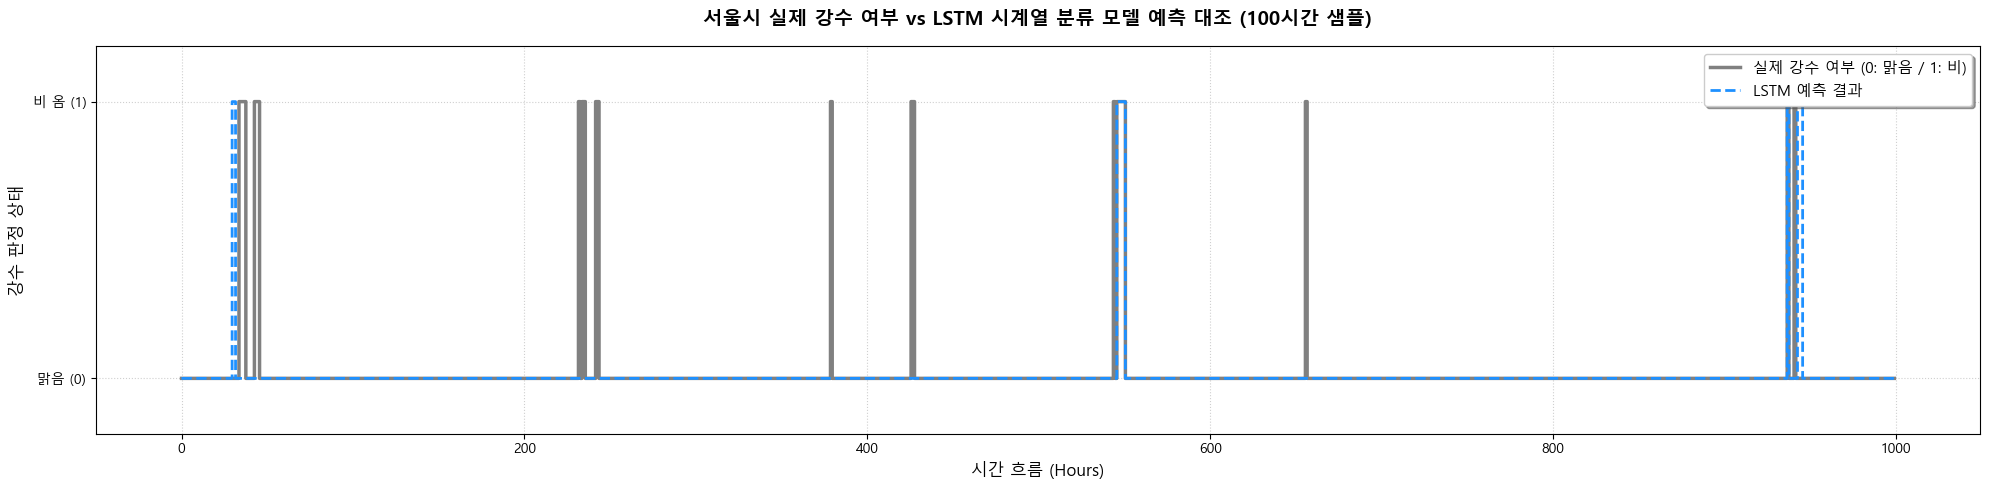

모든 파이프라인 과정이 성공적으로 완료되었습니다!


In [45]:

# 실제값과 예측값의 매칭 상태를 그래프로 출력
plt.figure(figsize=(20,5))
plt.plot(y_test.numpy(), label='실제 강수 여부 (0: 맑음 / 1: 비)', color='gray', drawstyle='steps-mid', linewidth=2.5)
plt.plot(test_predicted.numpy(), label='LSTM 예측 결과', color='dodgerblue', linestyle='--', drawstyle='steps-mid', linewidth=2)
plt.title('서울시 실제 강수 여부 vs LSTM 시계열 분류 모델 예측 대조 (100시간 샘플)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('시간 흐름 (Hours)', fontsize=12)
plt.ylabel('강수 판정 상태', fontsize=12)
plt.ylim(-0.2, 1.2)
plt.yticks([0, 1], ['맑음 (0)', '비 옴 (1)'])
plt.legend(loc='upper right', shadow=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("모든 파이프라인 과정이 성공적으로 완료되었습니다!")